In [2]:
import numpy as np 
import sympy as sp 
import matplotlib.pyplot as plt 


# Question 1

In [11]:
t = sp.Symbol('t')
Ixx = sp.Symbol('I_xx')
Iyy = sp.Symbol('I_yy')
Ixy = sp.Symbol('I_xy')
m = sp.Symbol('m')
Mx = sp.Symbol('M_x')

G_wing = sp.Matrix([[Ixx, -Ixy, 0, 0, 0, 0], 
                    [-Ixy, Iyy, 0, 0, 0, 0],
                    [0,0,Ixx + Iyy, 0, 0, 0],
                    [0,0,0,m,0,0],
                    [0,0,0,0,m,0],
                    [0,0,0,0,0,m]])

phi = sp.Function('phi')(t)
psi = sp.Function('psi')(t)
dphi = phi.diff(t)
dpsi = psi.diff(t)
ddphi = dphi.diff(t) 
ddpsi = dpsi.diff(t)

Ry = sp.Matrix([[sp.cos(phi), 0, sp.sin(phi)],
                [0,1,0],
                [-sp.sin(phi), 0, sp.cos(phi)]])

Rx = sp.Matrix([[1,0,0],
                [0, sp.cos(psi), -sp.sin(psi)],
                [0, sp.sin(psi), sp.cos(psi)]])

R = Ry * Rx 

T_wing = sp.Matrix([[R[0,0], R[0,1], R[0,2], 0],
                    [R[1,0], R[1,1], R[1,2], 0],
                    [R[2,0], R[2,1], R[2,2], 0],
                    [0,0,0,1]])

dT_dt = T_wing.diff(t)
Vb_skew = T_wing.inv() * dT_dt

wx = Vb_skew[2, 1]
wy = Vb_skew[0, 2]
wz = Vb_skew[1, 0]

vx = Vb_skew[0, 3]
vy = Vb_skew[1, 3]
vz = Vb_skew[2, 3]

Vb = sp.Matrix([wx, wy, wz, vx, vy, vz])
Vb.simplify()

KE = 0.5 * (Vb.T * G_wing * Vb)[0]
KE.simplify()

dT_dpsidot = KE.diff(dpsi)
d_dt_dT_dpsidot = dT_dpsidot.diff(t)
dT_dpsi = KE.diff(psi)

LHS = d_dt_dT_dpsidot - dT_dpsi

RHS = Mx - (LHS - Ixx * ddpsi)
RHS.simplify()


0.5*I_xx*sin(2*psi(t))*Derivative(phi(t), t)**2 + 1.0*I_xy*cos(psi(t))*Derivative(phi(t), (t, 2)) + 1.0*M_x

# Question 2

In [25]:
#part 6 
I = 1.0       
k = 4.0     
T = 1.0      
kappa = 0.5


omega = np.linspace(2.0, 10.0, 500)
r3_boundary = np.sqrt((omega**2) / kappa)
mu_boundary = ((omega**2 - k/(I*T**2)) * I * T * (1 + kappa)) / (kappa * r3_boundary)


Blue Region Test (5.0, 1.0) Max Real Part: -0.1339 
Red Region Test (2.0, 4.0) Max Real Part: 0.2003 


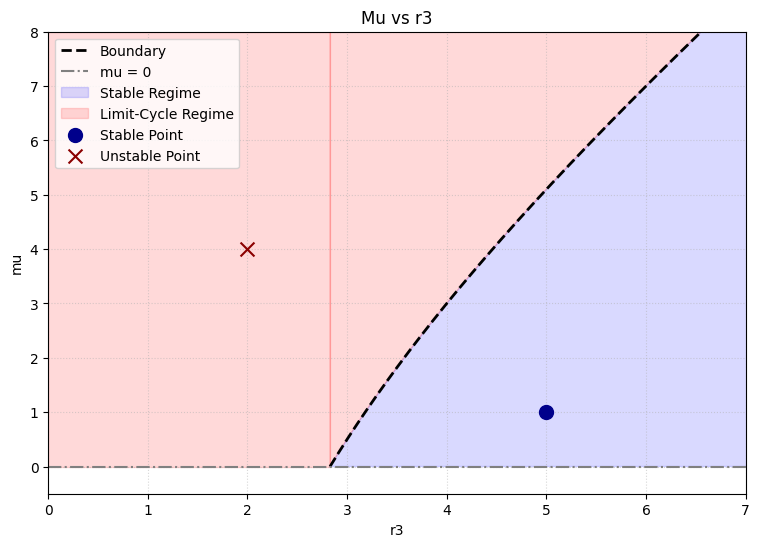

In [53]:
#part 7 
def get_eigenvalues(r3_val, mu_val):
    A = np.array([
        [0, 1, 0, 0],
        [-k / (I * T**2), 0, 1 / (I * T), 0],
        [0, 0, 0, 1],
        [0, -mu_val * kappa * (r3_val**2), -kappa * (r3_val**2), -r3_val * (1 + kappa)]
    ])
    return np.linalg.eigvals(A)

r3_blue, mu_blue = 5.0, 1.0
r3_red, mu_red = 2.0, 4.0

eigs_blue = get_eigenvalues(r3_blue, mu_blue)
eigs_red = get_eigenvalues(r3_red, mu_red)

print(f"Blue Region Test ({r3_blue}, {mu_blue}) Max Real Part: {np.max(np.real(eigs_blue)):.4f} ")
print(f"Red Region Test ({r3_red}, {mu_red}) Max Real Part: {np.max(np.real(eigs_red)):.4f} ")

plt.figure(figsize=(9, 6), dpi=100)

plt.plot(r3_boundary, mu_boundary, color='black', linestyle='--', linewidth=2, 
         label=r'Boundary')

plt.axhline(0, color='gray', linestyle='-.', linewidth=1.5, label=r'mu = 0 ')

plt.fill_between(r3_boundary, 0, mu_boundary, color='blue', alpha=0.15, 
                 label=r'Stable Regime')

plt.fill_between(r3_boundary, mu_boundary, 8, color='red', alpha=0.15, 
                 label=r'Limit-Cycle Regime')
plt.fill_between([0, r3_boundary[0]], [0, 0], [8.0, 8.0], color='red', alpha=0.15)

plt.scatter([r3_blue], [mu_blue], color='darkblue', s=100, marker='o', zorder=5, label='Stable Point')


plt.scatter([r3_red], [mu_red], color='darkred', s=100, marker='x', zorder=5, label='Unstable Point')


plt.title('Mu vs r3')
plt.xlabel(r'r3')
plt.ylabel(r'mu')
plt.xlim([0.0, 7.0])
plt.ylim([-0.5, 8.0])
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left')

plt.show()